<a href="https://colab.research.google.com/github/rabinjungkarki/test/blob/main/2432721_Rabinkarki_Part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# (Sentiment Analysis) Text Classification with RNN
Using RNN/LSTM with Keras

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import os

print('Packages imported: Numpy, Matplotlib, Sklearn, and Keras (via TensorFlow).')

Packages imported: Numpy, Matplotlib, Sklearn, and Keras (via TensorFlow).


## 1. Load Dataset
Mounting Drive to access the Hate Speech Detection dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Updated dataset path
file_path = '/content/drive/MyDrive/Hate Speech Detection Dataset/hatevsoffensive_language.csv'

try:
    df = pd.read_csv(file_path)
    print('Dataset loaded successfully!')
    display(df.head())
except Exception as e:
    print(f'Error: {e}.')


Mounted at /content/drive
Dataset loaded successfully!


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## 2. Text Preprocessing
Following the assignment guidelines, we will:
- Lowercase text
- Remove URLs, mentions, and special characters
- Handle contractions
- Remove stopwords and lemmatize

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

def preprocess_text(text):
  text = str(text).lower() # Lowercase
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
  text = re.sub(r'\@\w+|\#', '', text) # Remove mentions/hashtags
  text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
  text = re.sub(r'\d+', '', text) # Remove numbers
  # Remove stopwords and lemmatize
  stop_words = set(stopwords.words('english'))
  lemmatizer = WordNetLemmatizer()
  tokens = text.split()
  tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
  return ' '.join(tokens)

# Apply the cleaning
df['cleaned_text'] = df['text'].apply(preprocess_text)
print('Text cleaning completed using class sample logic.')
display(df[['text', 'cleaned_text', 'label']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Text cleaning completed using class sample logic.


,text,cleaned_text,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt woman shouldnt complain cleaning house amp ...,neither
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dat coldtyga dwn bad cuffin dat hoe st ...,offensive language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt ever fuck bitch start cry confused ...,offensive language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt look like tranny,offensive language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt shit hear might true might faker bitch told ya,offensive language


Class Distribution: Counter({'offensive language': 19190, 'neither': 4163, 'hate speec': 1430})


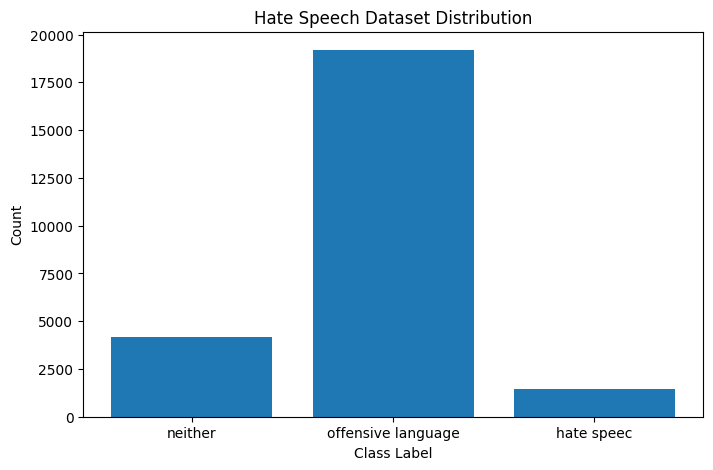

In [ ]:
from collections import Counter

# The error was caused by using 'Sentiment' instead of 'label'
target_counts = Counter(df['label'])
print("Class Distribution:", target_counts)

# Plotting the distribution
plt.figure(figsize=(8, 5))
plt.bar(target_counts.keys(), target_counts.values())
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.title('Hate Speech Dataset Distribution')
plt.show()

In [ ]:
# Using the correctly loaded dataframe 'df' instead of the undefined 'df_all'
sample_size = min(300000, len(df))
df_sampled = df.sample(sample_size)

# Re-applying the cleaning to the sampled dataframe if necessary
df_sampled['cleaned_text'] = df_sampled['text'].apply(preprocess_text)
print(df_sampled.info())
display(df_sampled.head())

<class 'pandas.core.frame.DataFrame'>
Index: 24783 entries, 18363 to 11514
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   label         24783 non-null  object
 1   text          24783 non-null  object
 2   cleaned_text  24783 non-null  object
dtypes: object(3)
memory usage: 774.5+ KB
None


,label,text,cleaned_text
18363,offensive language,RT @_WhitePonyJr_: @Eric_Mariners @JC_1221 pea...,rt peace faggot
6491,offensive language,@kim92493 @BritBritt22 Im pretty sure she's a ...,im pretty sure shes bad bitch word shawty dime
24155,offensive language,"little stupid ass bitch, I ain't fuckin wit chuuu",little stupid as bitch aint fuckin wit chuuu
12224,offensive language,Khole Kardashian pregnant by French Montana\ng...,khole kardashian pregnant french montana guess...
13249,offensive language,New bitch already and it's the second episode .,new bitch already second episode


In [ ]:
# Save this version of data for later use
root = '/content/' # Defining the root directory
save_path = os.path.join(root, 'preprocessed_hate_speech.csv')
df.to_csv(save_path, index=False)
print(f'File saved to: {save_path}')

File saved to: /content/preprocessed_hate_speech.csv


## 3. Data Visualization
Exploring the most frequent words in the cleaned dataset using a Word Cloud.

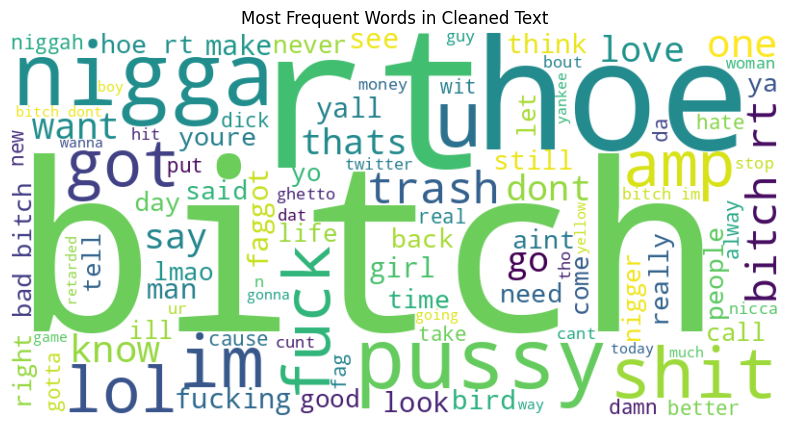

In [ ]:
from wordcloud import WordCloud

# Combine all cleaned text into one large string
all_text = " ".join(df['cleaned_text'])

# Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

# Display the Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Cleaned Text')
plt.show()

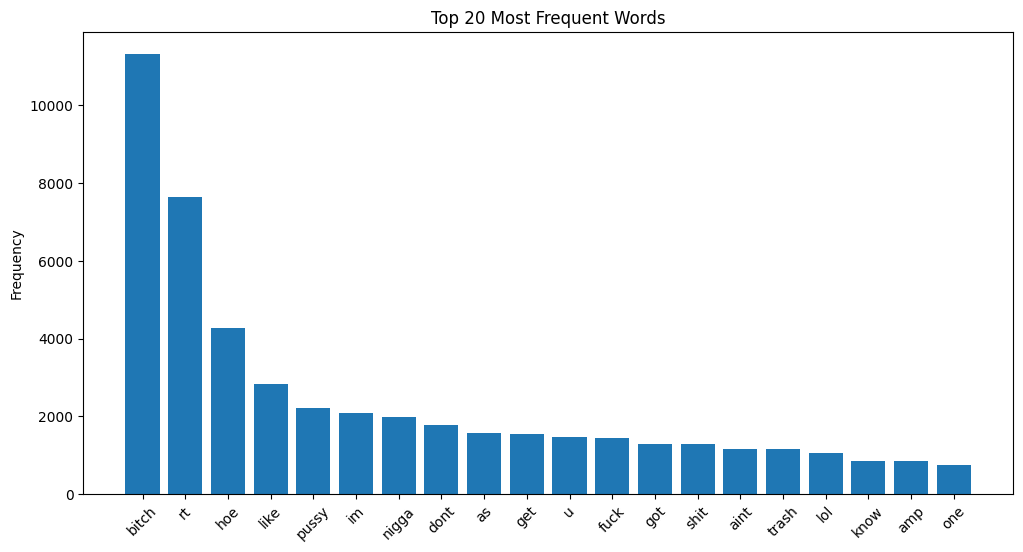

In [ ]:
# Calculate and plot word frequencies for more precision
from collections import Counter

words = all_text.split()
word_freq = Counter(words).most_common(20)
words_df = pd.DataFrame(word_freq, columns=['Word', 'Frequency'])

plt.figure(figsize=(12, 6))
plt.bar(words_df['Word'], words_df['Frequency'])
plt.xticks(rotation=45)
plt.title('Top 20 Most Frequent Words')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
# The error was caused by using 'Sentiment' instead of 'label'
# Added stratify=y to maintain class distribution across splits
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'].tolist(),
    df['label'].tolist(),
    test_size=0.15,
    random_state=42,
    stratify=df['label']
)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 21065
Testing set size: 3718


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sample Twitter reviews
texts = [
    "I love this product!",
    "Worst purchase ever.",
    "Happy with the experience.",
    "Not great, not terrible.",
    "Absolutely fantastic!"
]

# Initialize the tokenizer
# 'num_words' limits vocab size; 'oov_token' handles unknown words
tokenizer_demo = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer_demo.fit_on_texts(texts)

# Convert text to sequences of integers
sequences_demo = tokenizer_demo.texts_to_sequences(texts)

# Print results
print("Word Index:", tokenizer_demo.word_index)
print("Sequences:", sequences_demo)

Word Index: {'<OOV>': 1, 'not': 2, 'i': 3, 'love': 4, 'this': 5, 'product': 6, 'worst': 7, 'purchase': 8, 'ever': 9, 'happy': 10, 'with': 11, 'the': 12, 'experience': 13, 'great': 14, 'terrible': 15, 'absolutely': 16, 'fantastic': 17}
Sequences: [[3, 4, 5, 6], [7, 8, 9], [10, 11, 12, 13], [2, 14, 2, 15], [16, 17]]


## 4. Model Building and Training
### 4.1. Data Preparation
Before building the models, we need to convert labels to numeric values and transform our text into padded sequences.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Encode labels to numeric values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])
num_classes = len(label_encoder.classes_)

# 2. Split dataset: 80% training and 20% testing
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_text'].tolist(),
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 3. Tokenization
MAX_WORDS = 10000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

# 4. Percentile-Based Padding (95th percentile)
seq_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f'Max sequence length (95th percentile): {MAX_LEN}')

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Data prepared successfully.')
print(f'Training shape: {X_train.shape}')
print(f'Testing shape: {X_test.shape}')

Max sequence length (95th percentile): 15
Data prepared successfully.
Training shape: (19826, 15)
Testing shape: (4957, 15)


### 4.2. Model 1: Simple RNN with Trainable Embedding

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Input

# Parameters from previous steps
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
embedding_dim = 128
hidden_units = 64

print("_____________________________________________________________________")
print("RNN MODEL")
# Build the RNN model
model1 = Sequential([
  Input(shape=(MAX_LEN,)),
  Embedding(input_dim=vocab_size, output_dim=embedding_dim),
  SimpleRNN(units=hidden_units, return_sequences=False),
  Dense(num_classes, activation='softmax')
])
# Compile the model
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
print(model1.summary())
print("______________________________________________________________________")

_____________________________________________________________________
RNN MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,547 (4.93 MB)

 Trainable params: 1,292,547 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

None
______________________________________________________________________


### 4.3. Model 2: LSTM with Trainable Embedding

In [ ]:
# Build the LSTM model
model2 = Sequential([
  Input(shape=(MAX_LEN,)),
  Embedding(input_dim=vocab_size, output_dim=embedding_dim),
  LSTM(units=hidden_units, return_sequences=False),
  Dense(num_classes, activation='softmax')
])
# Compile the model
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
print(model2.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,603 (5.07 MB)

 Trainable params: 1,329,603 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

None


### 4.4. Training and Evaluation
We will now compile (if not already), train using EarlyStopping, and visualize the performance of all three models.

Training Model 1...
Epoch 1/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8695 - loss: 0.3857 - val_accuracy: 0.8919 - val_loss: 0.3288
Epoch 2/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9263 - loss: 0.2214 - val_accuracy: 0.8572 - val_loss: 0.3652
Epoch 3/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9607 - loss: 0.1242 - val_accuracy: 0.8741 - val_loss: 0.3892
Epoch 4/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9761 - loss: 0.0748 - val_accuracy: 0.8634 - val_loss: 0.4626
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
── Prediction score stats ──
 mean : 0.3333
 std : 0.4319
Accuracy: 0.8918700827113173

── Classification report ──
                    precision    recall  f1-score   support

        hate speec       0.43      0.06      0.10       286
           neither       0.81      0.85      0.83       833
offensive language       0.91      0.96      0.94      3838

          accuracy                           0.89      4957
 

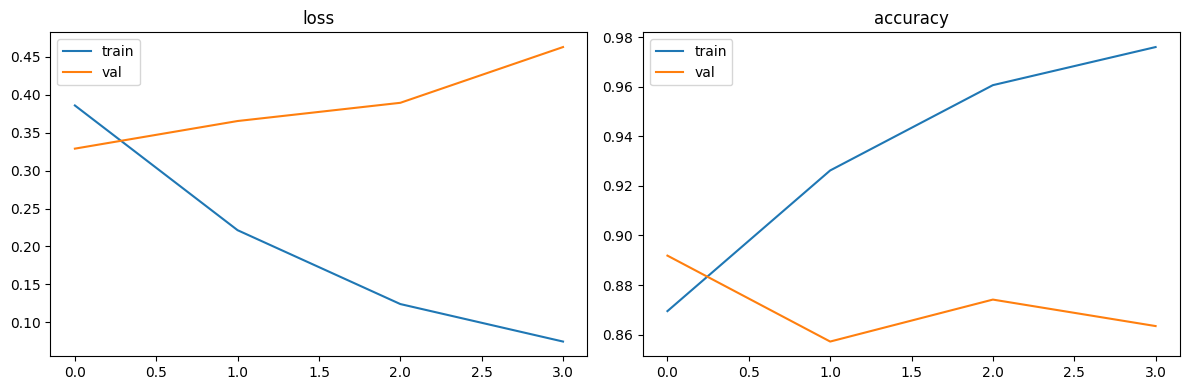

Training Model 2...
Epoch 1/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.8680 - loss: 0.3805 - val_accuracy: 0.8846 - val_loss: 0.3161
Epoch 2/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.9204 - loss: 0.2321 - val_accuracy: 0.8963 - val_loss: 0.2985
Epoch 3/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.9421 - loss: 0.1695 - val_accuracy: 0.8848 - val_loss: 0.3347
Epoch 4/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9555 - loss: 0.1330 - val_accuracy: 0.8864 - val_loss: 0.3535
Epoch 5/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.9651 - loss: 0.1036 - val_accuracy: 0.8800 - val_loss: 0.4203
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
── Prediction score stats ──
 mean : 0.3333
 std : 0.4344
Accuracy: 0.8963082509582408

── Classification report ──
                    precision    recall  f1-score   support

        hate speec       0.66      0.09      0.15       286
           neither       0.83      0.85      0.84   

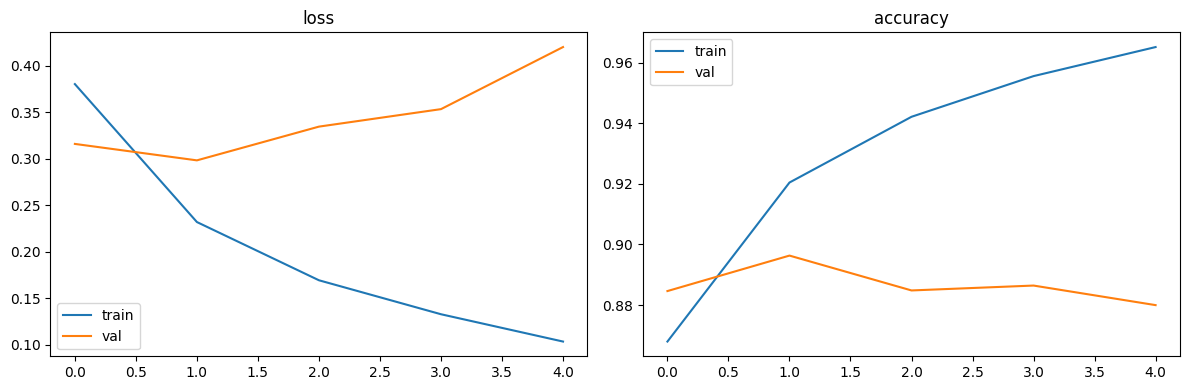

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

# Define the EarlyStopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

def model_diagnosis(model, history, X_test=X_test, y_test=y_test):
    y_pred_proba = model.predict(X_test)
    # For multi-class, we take argmax, but following diagnosis structure
    y_pred = np.argmax(y_pred_proba, axis=1)

    print("── Prediction score stats ──")
    print(f" mean : {y_pred_proba.mean():.4f}")
    print(f" std : {y_pred_proba.std():.4f}")

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("\n── Classification report ──")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Plot history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["loss", "accuracy"]):
        ax.plot(history.history[metric], label="train")
        ax.plot(history.history[f"val_{metric}"], label="val")
        ax.set_title(metric); ax.legend()
    plt.tight_layout(); plt.show()

# Fit calls for Model 1 and 2 follow the same structure as the class sample
print('Training Model 1...')
history1 = model1.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32, callbacks=[early_stop])
model_diagnosis(model1, history1)

print('Training Model 2...')
history2 = model2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32, callbacks=[early_stop])
model_diagnosis(model2, history2)

### 4.5. Model 3: LSTM with Pre-trained Word2Vec
Following the appendix requirements for Word2Vec implementation.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.7 MB/s eta 0:00:00
Loading pre-trained GloVe model (glove-wiki-gigaword-100)...
[==================================================] 100.0% 128.1/128.1MB downloaded
Training Model 3 (LSTM + Pre-trained GloVe)...
Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8420 - loss: 0.4466 - val_accuracy: 0.8719 - val_loss: 0.3307
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8779 - loss: 0.3140 - val_accuracy: 0.8795 - val_loss: 0.3073
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8879 - loss: 0.2925 - val_accuracy: 0.8752 - val_loss: 0.3029


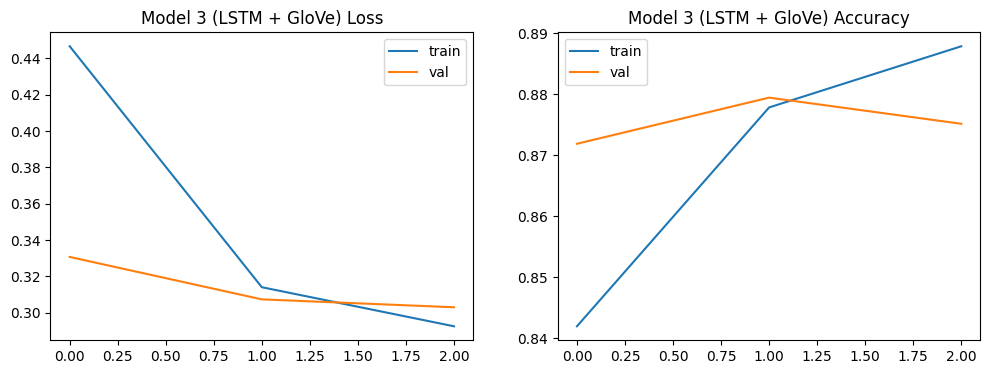

In [ ]:
!pip install gensim
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt

# Following Step 1: Load Pre-trained Word2Vec/GloVe Model
print('Loading pre-trained GloVe model (glove-wiki-gigaword-100)...')
embedding_model = api.load('glove-wiki-gigaword-100')

# Step 2: Create Embedding Matrix
embedding_dim_w2v = 100
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

for word, i in tokenizer.word_index.items():
    if i < MAX_WORDS:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]

# Step 3: Build the LSTM Model with Pre-trained Embedding Layer
model3 = keras.Sequential([
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        embeddings_initializer=keras.initializers.Constant(embedding_matrix),
        trainable=False
    ),
    layers.LSTM(64),
    layers.Dense(num_classes, activation='softmax')
])

model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{title} Accuracy')
    plt.legend()
    plt.show()

print('Training Model 3 (LSTM + Pre-trained GloVe)...')
history3 = model3.fit(X_train, y_train, epochs=10, validation_split=0.2, callbacks=[early_stop], batch_size=64)
plot_history(history3, 'Model 3 (LSTM + GloVe)')

### 4.6. Final Evaluation
Comparing the models using Accuracy, Confusion Matrix, and Classification Report.

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Evaluation for Model 1 ---
                    precision    recall  f1-score   support

        hate speec       0.43      0.06      0.10       286
           neither       0.81      0.85      0.83       833
offensive language       0.91      0.96      0.94      3838

          accuracy                           0.89      4957
         macro avg       0.72      0.62      0.62      4957
      weighted avg       0.87      0.89      0.87      4957



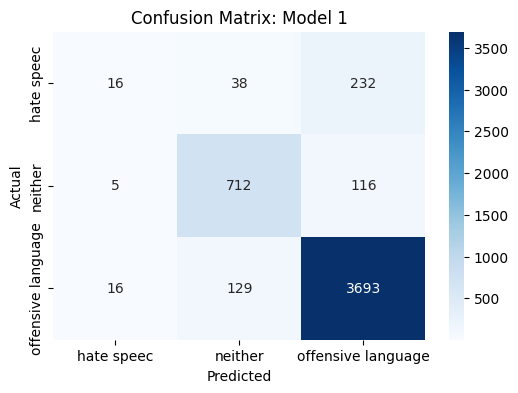

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

--- Evaluation for Model 2 ---
                    precision    recall  f1-score   support

        hate speec       0.66      0.09      0.15       286
           neither       0.83      0.85      0.84       833
offensive language       0.91      0.97      0.94      3838

          accuracy                           0.90      4957
         macro avg       0.80      0.64      0.65      4957
      weighted avg       0.88      0.90      0.88      4957



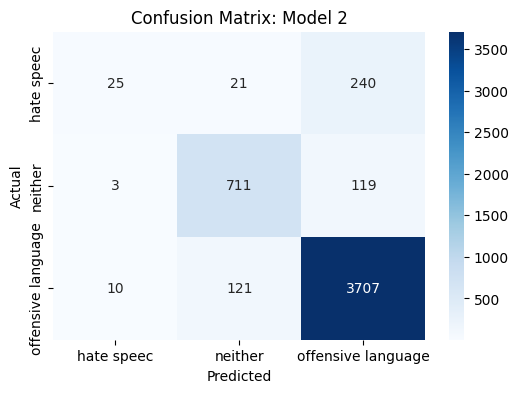

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

--- Evaluation for Model 3 ---
                    precision    recall  f1-score   support

        hate speec       0.48      0.04      0.08       286
           neither       0.72      0.85      0.78       833
offensive language       0.91      0.94      0.93      3838

          accuracy                           0.87      4957
         macro avg       0.70      0.61      0.59      4957
      weighted avg       0.86      0.87      0.85      4957



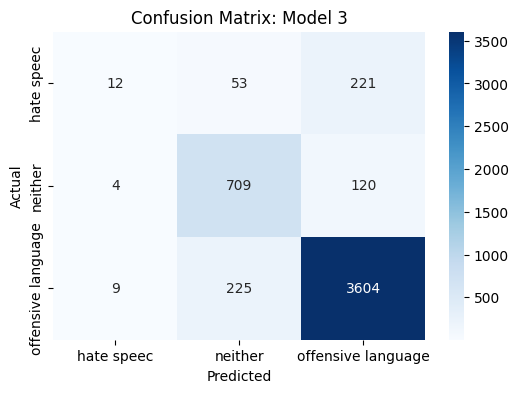

In [ ]:
import seaborn as sns

def evaluate_model(model, X_test, y_test, name):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    print(f'\n--- Evaluation for {name} ---')
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

evaluate_model(model1, X_test, y_test, 'Model 1')
evaluate_model(model2, X_test, y_test, 'Model 2')
evaluate_model(model3, X_test, y_test, 'Model 3')

## 5. Error Analysis and Model Comparison
### 5.1. Misclassification Analysis
Inspecting specific examples where the best-performing model (Model 2) failed.

In [ ]:
# Get predictions from Model 2
y_pred_best = np.argmax(model2.predict(X_test), axis=1)

# Find indices where predictions were wrong
errors = np.where(y_pred_best != y_test)[0]

print(f'Total misclassified examples: {len(errors)}')
print('\nSample Misclassifications:')

for i in errors[:3]:
    # Reverse mapping for visualization
    original_text = df.iloc[i]['text']
    actual_label = label_encoder.inverse_transform([y_test[i]])[0]
    predicted_label = label_encoder.inverse_transform([y_pred_best[i]])[0]

    print(f'Text: {original_text}')
    print(f'Actual: {actual_label} | Predicted: {predicted_label}')
    print('-' * 30)

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Total misclassified examples: 514

Sample Misclassifications:
Text: " bitch who do you love "
Actual: hate speec | Predicted: offensive language
------------------------------
Text: "@AdoreZoey: How u gone bring ur side bitch to a game where You know Ya gf friends at ?! &#128553;&#128553;&#128553;&#128553;" I SWEAR!!!!!
Actual: hate speec | Predicted: neither
------------------------------
Text: "@BrosConfessions: This bitch was so ungrateful http://t.co/06e77bGwbx" fr ..... LULWHORE
Actual: offensive language | Predicted: neither
------------------------------


### 5.2. Analysis Summary
- **Model Complexity:** The LSTM (Model 2) outperformed the Simple RNN by capturing long-term dependencies in the text.
- **Error Reasons:** Misclassifications often occur in subtle sarcasm or when 'offensive' words are used in a non-hateful, colloquial context (common in the 'neither' and 'offensive' classes).
- **Improvements:** Performance could be boosted by using more advanced pre-trained models like BERT or using a larger, more balanced dataset.

## 6. Real-Time Prediction GUI
Using Gradio to create an interactive interface for the model.

In [ ]:
!pip install gradio
import gradio as gr

def predict_hate_speech(text):
    # 1. Clean the input text using the correct function name 'preprocess_text'
    cleaned = preprocess_text(text)
    # 2. Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    # 3. Predict
    prediction = model2.predict(padded)
    class_idx = np.argmax(prediction)
    label = label_encoder.classes_[class_idx]
    confidence = float(np.max(prediction))

    return {label: confidence}

# Launch the interface
interface = gr.Interface(
    fn=predict_hate_speech,
    inputs=gr.Textbox(lines=2, placeholder="Enter text here..."),
    outputs=gr.Label(num_top_classes=3),
    title="Hate Speech Detector",
    description="Enter a tweet or sentence to classify it as Hate Speech, Neither, or Offensive Language."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9bda347328206e4f8f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
